# Session 3A — Quantitative evaluation

Evaluate inferred proteins with pointwise accuracy metrics and spatial-coherence diagnostics.

Work through the parts in order. Each part ends by writing its existing JSON checkpoint,
so the consolidation changes file organization without removing pause/resume milestones.


In [1]:
from pathlib import Path
import sys

# Locates the cloned tutorial in Google Colab after Session 0 setup.
candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
colab_root = Path("/content/ECCB-2026-Tutorial/hands-on_tutorial")
if colab_root.is_dir():
    candidates.insert(0, colab_root.resolve())

for candidate in candidates:
    if (candidate / "src" / "dgat_tutorial").is_dir():
        tutorial_root = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find hands-on_tutorial/. In Colab, run notebooks/session_00/00_colab_setup.ipynb first."
    )

sys.path.insert(0, str(tutorial_root / "src"))

from dgat_tutorial.checkpoints import tutorial_paths, write_checkpoint

paths = tutorial_paths(tutorial_root)
print(f"Tutorial root: {paths.root}")


Tutorial root: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial


## Session 3 · Part 1 — Evaluate pointwise prediction accuracy

**Goal:** quantify how well inferred abundance tracks measured abundance for every protein. Published
DGAT reporting emphasized **Spearman correlation and RMSE**; Pearson is retained as a secondary linear
check. Neither metric alone proves spatial concordance—that is Part 2.

This is an evaluation notebook: it requires the matching official Tonsil RNA/ADT assets and never pairs
the committed predictions with any other observations. Before treating Tonsil as held-out accuracy,
confirm with the DGAT authors that Tonsil was excluded from training and checkpoint selection
(`tonsil_held_out` in the prediction metadata).


### 1. Align observed and predicted proteins and read provenance


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dgat_tutorial.checkpoints import preferred_prediction_path
from dgat_tutorial.data import load_tutorial_data
from dgat_tutorial.dgat import load_prediction_metadata, load_prediction_table
from dgat_tutorial.evaluation import (
    alignment_report,
    corresponding_rna_baseline,
    protein_correlations,
)
from dgat_tutorial.plotting import plot_correlation_bar
from dgat_tutorial.processing import normalize_rna_dgat, prepare_evaluation_proteins

dataset = load_tutorial_data(paths.raw_data)
prediction_path = preferred_prediction_path(paths)
predicted = load_prediction_table(str(prediction_path))
metadata = load_prediction_metadata(prediction_path)
if metadata:
    print(f"Prediction method: {metadata.get('method')}")
    print(f"tonsil_held_out: {metadata.get('tonsil_held_out')}")
    print(f"training_samples: {metadata.get('training_samples')}")
    print(f"Evaluation note: {metadata.get('evaluation_note')}")
    if metadata.get("tonsil_held_out") is not True:
        print(
            "WARNING: tonsil_held_out is not True in the sidecar. "
            "Do not treat these scores as confirmed held-out accuracy."
        )

# DGAT predictions are on the CLR protein scale used in training/evaluation.
# Score against CLR-normalized observed ADT (never raw counts).
observed_raw = dataset.proteins
report = alignment_report(observed_raw, predicted)
print(report)
if report["spots_only_in_observed"] or report["spots_only_in_predicted"]:
    print("WARNING: spot ID sets differ; evaluation uses the intersection and reports mismatches above.")
if report["proteins_only_in_observed"] or report["proteins_only_in_predicted"]:
    print("WARNING: protein panels differ; only shared proteins are scored.")

common_spots = observed_raw.index.intersection(predicted.index)
common_proteins = list(report["proteins_evaluated"])
if not len(common_spots) or not common_proteins:
    raise ValueError("Observed and predicted tables must share spot IDs and canonical protein names.")
observed = prepare_evaluation_proteins(observed_raw.loc[common_spots, common_proteins])
predicted = predicted.loc[common_spots, common_proteins]

scale_summary = pd.DataFrame({
    "observed_clr_mean": observed.mean(),
    "predicted_mean": predicted.mean(),
    "observed_clr_std": observed.std(),
    "predicted_std": predicted.std(),
})
display(scale_summary.head())

correlations = protein_correlations(observed, predicted)
correlations


Prediction method: official_dgat
tonsil_held_out: None
training_samples: None
Evaluation note: Official pretrained DGAT inference via fill_genes + preprocess_ST + protein_predict. Before treating Tonsil scores as held-out accuracy, confirm exclusion from training/checkpoint selection with the DGAT authors.
{'n_common_spots': 4191, 'n_common_proteins': 31, 'spots_only_in_observed': ['CGTGTAGACACCTTCC-1', 'CGTGTAGTATTCTTGG-1', 'GCGGTCGTTGATCTTG-1'], 'spots_only_in_predicted': [], 'proteins_only_in_observed': ['mouse_IgG1k', 'mouse_IgG2a', 'mouse_IgG2bk', 'rat_IgG2a'], 'proteins_only_in_predicted': [], 'proteins_evaluated': ['CD163', 'CR2', 'PCNA', 'VIM', 'KRT5', 'CD68', 'CEACAM8', 'PTPRC_1', 'HLA_DRA', 'PAX5', 'SDC1', 'PTPRC_2', 'CD8A', 'BCL2', 'CD19', 'PDCD1', 'ACTA2', 'FCGR3A', 'ITGAX', 'CXCR5', 'EPCAM', 'MS4A1', 'CD3E', 'CD14', 'CD40', 'PECAM1', 'CD4', 'ITGAM', 'CD27', 'CCR7', 'CD274']}


/Users/zmengaf/miniconda3/envs/eccb-dgat-tutorial/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/zmengaf/miniconda3/envs/eccb-dgat-tutorial/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


,observed_clr_mean,predicted_mean,observed_clr_std,predicted_std
CD163,0.698183,0.673044,0.104084,0.072137
CR2,0.695851,0.695611,0.073155,0.060581
PCNA,0.744602,0.758361,0.312149,0.292630
VIM,0.743537,0.729699,0.276857,0.250989
KRT5,0.924749,0.956603,0.873548,0.818124


Alignment report before evaluation: common_spots=4191, common_proteins=31, spots_only_observed=0, spots_only_predicted=0, proteins_only_observed=[], proteins_only_predicted=[]


,protein,spearman,pearson,rmse
4,KRT5,0.961939,0.972805,0.207237
9,PAX5,0.955724,0.952709,0.111294
19,CXCR5,0.952353,0.945967,0.107183
22,CD3E,0.951756,0.977522,0.098865
18,ITGAX,0.950405,0.953187,0.121776
12,CD8A,0.949355,0.961729,0.120731
21,MS4A1,0.946018,0.942174,0.115714
8,HLA_DRA,0.943853,0.942118,0.124155
30,CD274,0.941217,0.947530,0.112263
25,PECAM1,0.924900,0.922919,0.103662


#### Figure 10 — Accuracy across the complete protein panel (Spearman)


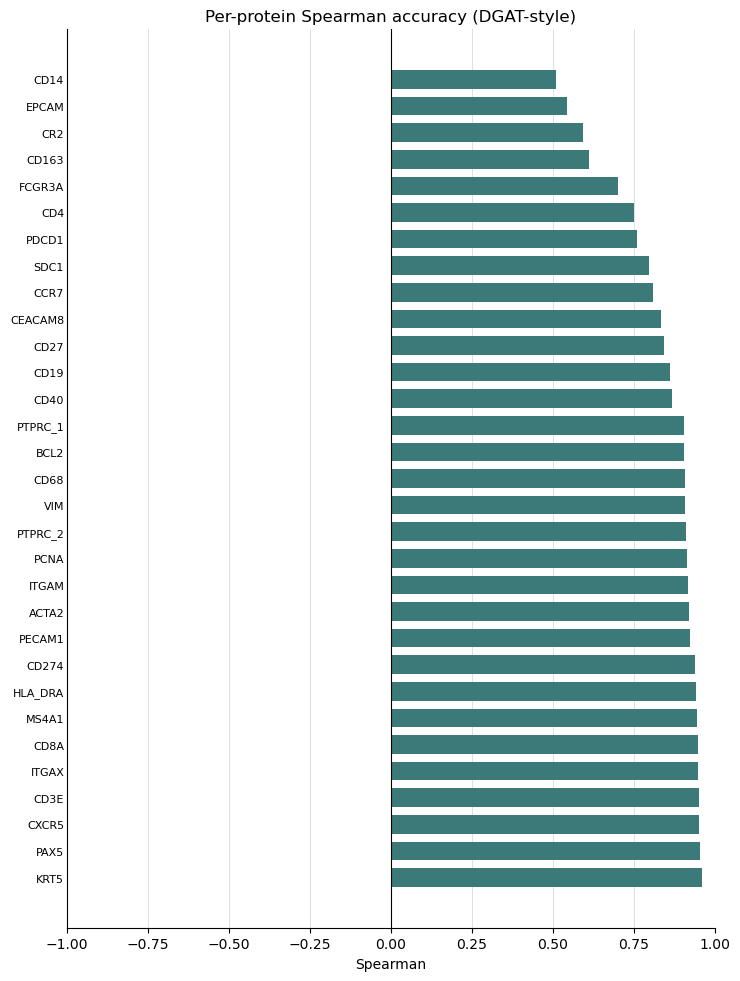

Panel summary: median Spearman=0.908, median Pearson=0.917, median RMSE=0.107


,protein,spearman,pearson,rmse
4,KRT5,0.961939,0.972805,0.207237
9,PAX5,0.955724,0.952709,0.111294
19,CXCR5,0.952353,0.945967,0.107183
22,CD3E,0.951756,0.977522,0.098865
18,ITGAX,0.950405,0.953187,0.121776
12,CD8A,0.949355,0.961729,0.120731
21,MS4A1,0.946018,0.942174,0.115714
8,HLA_DRA,0.943853,0.942118,0.124155
30,CD274,0.941217,0.947530,0.112263
25,PECAM1,0.924900,0.922919,0.103662


In [3]:
ax = plot_correlation_bar(correlations, metric="spearman")
ax.set_title("Per-protein Spearman accuracy (DGAT-style)")
correlation_bar_path = paths.figures / "session03_prediction_correlations.png"
plt.tight_layout(); plt.savefig(correlation_bar_path, dpi=160, bbox_inches="tight"); plt.show()

rmse_summary = correlations[["protein", "spearman", "pearson", "rmse"]].copy()
print(
    "Panel summary: "
    f"median Spearman={rmse_summary['spearman'].median():.3f}, "
    f"median Pearson={rmse_summary['pearson'].median():.3f}, "
    f"median RMSE={rmse_summary['rmse'].median():.3f}"
)
display(rmse_summary.head(10))


### 2. Corresponding-RNA baseline (nonspatial)


In [4]:
# Use the same RNA normalize/scale recipe as DGAT training for a fairer nonspatial baseline.
# Compare ranks (Spearman) primarily; RMSE across RNA vs CLR-protein units remains secondary.
transcripts = normalize_rna_dgat(dataset.transcripts.loc[common_spots])
rna_baseline = corresponding_rna_baseline(transcripts, observed)
rna_correlations = protein_correlations(observed[rna_baseline.columns], rna_baseline)
comparison = (
    correlations.set_index("protein")[["spearman", "rmse"]]
    .join(rna_correlations.set_index("protein")[["spearman", "rmse"]], rsuffix="_rna")
    .rename(columns={"spearman": "spearman_dgat", "rmse": "rmse_dgat",
                     "spearman_rna": "spearman_rna", "rmse_rna": "rmse_rna"})
    .dropna()
    .sort_values("spearman_dgat", ascending=False)
)
print(f"Corresponding-RNA baseline proteins matched: {len(comparison)}")
display(comparison.head(10))
baseline_path = paths.results / "session03_dgat_vs_rna_baseline.csv"
comparison.to_csv(baseline_path)


Alignment report before evaluation: common_spots=4191, common_proteins=30, spots_only_observed=0, spots_only_predicted=0, proteins_only_observed=[], proteins_only_predicted=[]
Corresponding-RNA baseline proteins matched: 30


,spearman_dgat,rmse_dgat,spearman_rna,rmse_rna
protein,,,,
KRT5,0.961939,0.207237,0.648990,1.142035
PAX5,0.955724,0.111294,0.770345,1.079920
CXCR5,0.952353,0.107183,0.534249,1.150178
CD3E,0.951756,0.098865,0.700335,1.078052
ITGAX,0.950405,0.121776,0.236590,1.243558
CD8A,0.949355,0.120731,0.457307,1.177276
MS4A1,0.946018,0.115714,0.447317,1.166212
CD274,0.941217,0.112263,0.313017,1.181632
PECAM1,0.924900,0.103662,0.563308,1.139454


#### Figure 11 — Observed versus predicted abundance for representative proteins


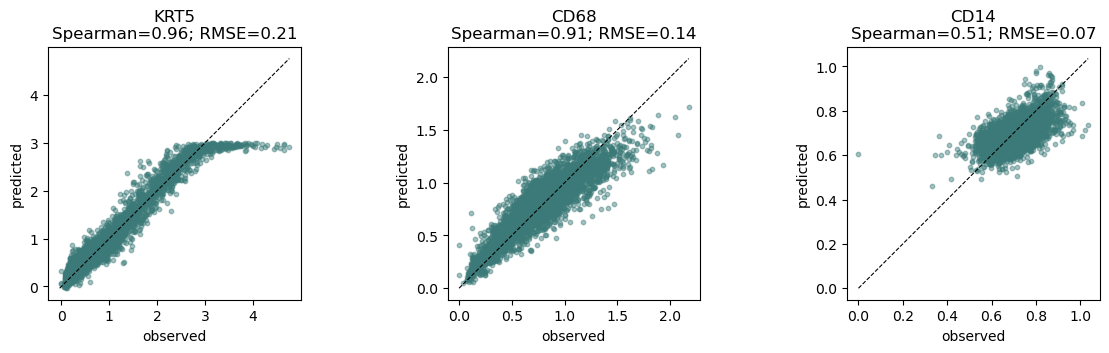

In [5]:
ranked = correlations.sort_values("spearman")
representative = list(dict.fromkeys([
    ranked.iloc[-1]["protein"], ranked.iloc[len(ranked)//2]["protein"], ranked.iloc[0]["protein"]
]))
fig, axes = plt.subplots(1, len(representative), figsize=(4 * len(representative), 3.6), squeeze=False)
for ax, protein in zip(axes.ravel(), representative):
    row = correlations.set_index("protein").loc[protein]
    ax.scatter(observed[protein], predicted[protein], s=10, alpha=0.45, color="#3b7a78")
    lims = [
        min(observed[protein].min(), predicted[protein].min()),
        max(observed[protein].max(), predicted[protein].max()),
    ]
    ax.plot(lims, lims, color="black", linewidth=0.8, linestyle="--")
    ax.set(
        xlabel="observed", ylabel="predicted",
        title=f"{protein}\nSpearman={row['spearman']:.2f}; RMSE={row['rmse']:.2f}",
    )
    ax.set_aspect("equal", adjustable="box")
scatter_path = paths.figures / "session03_observed_vs_predicted_scatter.png"
fig.tight_layout(); fig.savefig(scatter_path, dpi=160, bbox_inches="tight"); plt.show()


**How to read it:** a high Spearman with a compressed prediction range can still underestimate
biological extremes (check RMSE and the diagonal). Outliers may be technical, but they can also identify
rare regions worth inspecting spatially. Avoid summarizing a 31-protein panel with only its mean correlation.


In [6]:
table_path = paths.results / "session03_prediction_correlations.csv"
correlations.to_csv(table_path, index=False)
manifest = write_checkpoint(
    "3.1", [table_path, baseline_path, correlation_bar_path, scatter_path],
    summary={
        "spots": len(common_spots),
        "proteins_evaluated": len(correlations),
        "median_spearman": float(correlations["spearman"].median()),
        "median_rmse": float(correlations["rmse"].median()),
    },
    start=paths.root,
)
print(f"Checkpoint written: {manifest}")


Checkpoint written: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/checkpoints/session_03/part_3_1.json


### Check

Name a high-, middle-, and low-performing protein by Spearman/RMSE and describe whether errors look like
noise, range compression, or systematic bias. Note whether DGAT beats the corresponding-RNA baseline.


## Session 3 · Part 2 — Evaluate spatial coherence

**Goal:** test whether DGAT preserves local tissue structure. Comparing univariate Moran's I for
observed versus predicted values shows whether the two matrices have similar *overall autocorrelation*.
That is **not** the same as spatial concordance: a highly smoothed but misplaced prediction can still
match Moran's I. We therefore also report residual Moran's I and a simple bivariate Moran's I between
observed and predicted maps.


### 1. Load aligned observations, predictions, and coordinates


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from dgat_tutorial.checkpoints import preferred_prediction_path
from dgat_tutorial.data import load_tutorial_data
from dgat_tutorial.dgat import load_prediction_table
from dgat_tutorial.evaluation import (
    alignment_report,
    bivariate_morans_i,
    morans_i,
    residual_morans_i,
)

from dgat_tutorial.processing import prepare_evaluation_proteins

dataset = load_tutorial_data(paths.raw_data)
predicted = load_prediction_table(str(preferred_prediction_path(paths)))
report = alignment_report(dataset.proteins, predicted)
print(report)
common_spots = dataset.spots.index.intersection(dataset.proteins.index).intersection(predicted.index)
common_proteins = list(report["proteins_evaluated"])
if not len(common_spots) or not common_proteins:
    raise ValueError("Observed and predicted data do not share both spot IDs and protein names.")
spots = dataset.spots.loc[common_spots]
observed = prepare_evaluation_proteins(dataset.proteins.loc[common_spots, common_proteins])
predicted = predicted.loc[common_spots, common_proteins]


{'n_common_spots': 4191, 'n_common_proteins': 31, 'spots_only_in_observed': ['CGTGTAGACACCTTCC-1', 'CGTGTAGTATTCTTGG-1', 'GCGGTCGTTGATCTTG-1'], 'spots_only_in_predicted': [], 'proteins_only_in_observed': ['mouse_IgG1k', 'mouse_IgG2a', 'mouse_IgG2bk', 'rat_IgG2a'], 'proteins_only_in_predicted': [], 'proteins_evaluated': ['CD163', 'CR2', 'PCNA', 'VIM', 'KRT5', 'CD68', 'CEACAM8', 'PTPRC_1', 'HLA_DRA', 'PAX5', 'SDC1', 'PTPRC_2', 'CD8A', 'BCL2', 'CD19', 'PDCD1', 'ACTA2', 'FCGR3A', 'ITGAX', 'CXCR5', 'EPCAM', 'MS4A1', 'CD3E', 'CD14', 'CD40', 'PECAM1', 'CD4', 'ITGAM', 'CD27', 'CCR7', 'CD274']}


### 2. Calculate observed/predicted Moran's I plus residual and bivariate concordance


In [9]:
moran_table = pd.DataFrame([
    {
        "protein": protein,
        "observed_morans_i": morans_i(observed[protein], spots),
        "predicted_morans_i": morans_i(predicted[protein], spots),
        "residual_morans_i": residual_morans_i(observed[protein], predicted[protein], spots),
        "bivariate_morans_i": bivariate_morans_i(observed[protein], predicted[protein], spots),
    }
    for protein in common_proteins
])
moran_table["difference"] = moran_table["predicted_morans_i"] - moran_table["observed_morans_i"]
moran_table.sort_values("difference")


,protein,observed_morans_i,predicted_morans_i,residual_morans_i,bivariate_morans_i,difference
9,PAX5,0.801510,0.785316,0.298803,0.779257,-0.016194
22,CD3E,0.848464,0.854967,0.336693,0.844449,0.006503
10,SDC1,0.679439,0.686032,0.380462,0.629426,0.006593
30,CD274,0.651389,0.658177,0.251302,0.641619,0.006789
2,PCNA,0.724888,0.738627,0.430859,0.701250,0.013740
21,MS4A1,0.822520,0.837933,0.509280,0.803384,0.015413
27,ITGAM,0.615634,0.631935,0.258761,0.611076,0.016301
8,HLA_DRA,0.864086,0.885198,0.351311,0.856505,0.021113
19,CXCR5,0.708595,0.730032,0.427936,0.700078,0.021436
4,KRT5,0.664258,0.688799,0.272312,0.669187,0.024540


#### Figure 12 — Observed versus predicted spatial autocorrelation


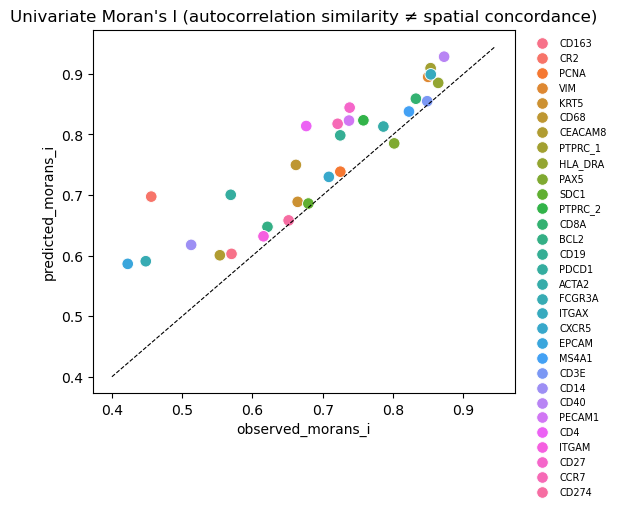

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=moran_table, x="observed_morans_i", y="predicted_morans_i", hue="protein", s=70, ax=ax)
limits = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(limits, limits, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Univariate Moran's I (autocorrelation similarity ≠ spatial concordance)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, frameon=False)
moran_scatter_path = paths.figures / "session03_morans_i.png"
fig.tight_layout(); fig.savefig(moran_scatter_path, dpi=160, bbox_inches="tight"); plt.show()


#### Figure 13 — Smoothing bias and residual spatial structure


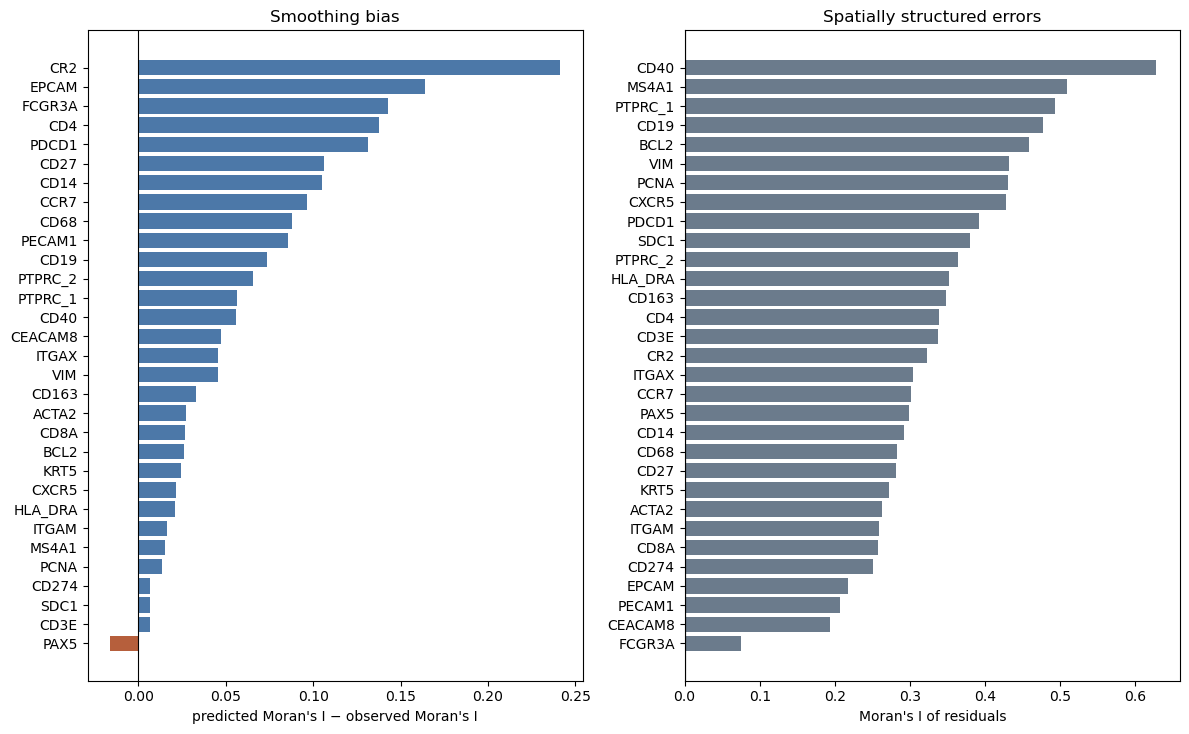

Median bivariate Moran's I (observed vs predicted): 0.700


In [11]:
ordered = moran_table.sort_values("difference")
fig, axes = plt.subplots(1, 2, figsize=(12, max(4, 0.24 * len(ordered))))
colors = ["#b65f3c" if value < 0 else "#4c78a8" for value in ordered["difference"]]
axes[0].barh(ordered["protein"], ordered["difference"], color=colors)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set(xlabel="predicted Moran's I − observed Moran's I", title="Smoothing bias")
ordered_res = moran_table.sort_values("residual_morans_i")
axes[1].barh(ordered_res["protein"], ordered_res["residual_morans_i"], color="#6b7b8c")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set(xlabel="Moran's I of residuals", title="Spatially structured errors")
difference_path = paths.figures / "session03_morans_i_difference.png"
fig.tight_layout(); fig.savefig(difference_path, dpi=160, bbox_inches="tight"); plt.show()
print(
    "Median bivariate Moran's I (observed vs predicted): "
    f"{moran_table['bivariate_morans_i'].median():.3f}"
)


Positive univariate differences can indicate over-smoothing; negative differences can indicate lost
spatial signal. Residual Moran's I near zero suggests unstructured errors; large residual Moran's I
suggests spatially localized mistakes. Interpretation depends on the neighborhood radius and tissue
geometry—report the rule and compare proteins under the same rule. Stronger tests (permutation p-values,
spatial-lag correlation, neighborhood sensitivity) are recommended before publication.


In [12]:
table_path = paths.results / "session03_morans_i.csv"
moran_table.to_csv(table_path, index=False)
manifest = write_checkpoint(
    "3.2", [table_path, moran_scatter_path, difference_path],
    summary={
        "proteins_evaluated": len(moran_table),
        "median_bivariate_morans_i": float(moran_table["bivariate_morans_i"].median()),
    },
    start=paths.root,
)
print(f"Checkpoint written: {manifest}")


Checkpoint written: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/checkpoints/session_03/part_3_2.json


### Check

Find one protein whose pointwise correlation and spatial-coherence result agree, and one where they tell
different stories. Prefer residual or bivariate Moran when univariate Moran's I alone looks reassuring.
